In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import pathlib
import numpy as np

import cogwheel.data
import cogwheel.posterior
import cogwheel.sampling
from cogwheel.likelihood.marginalization.coherent_score_lensing import CoherentScoreLensing

### create event data

In [2]:
eventname = 'GWexample'
seed = 12
asd_funcs = list(cogwheel.data.ASDS)

# Gaussian noise
event_data = cogwheel.data.EventData.gaussian_noise(
    eventname, duration=128.0, detector_names='HLV', fmax=512.0,
    asd_funcs=asd_funcs, tgps=0.0, seed=seed)

# inject signal
injection_dic = {
    'f_ref' : 100.0,
    'm1' : 60,  # by convention, the heavier object. in Msun
    'm2' : 10,    # in Msun
    's1z' : 0.,
    's2z' : 0.,
    'psi' : 0.5,       # polarization angle
    'iota' : 0.5 * np.pi,      # inclination angle
    's1x_n' : 0.,
    's1y_n' : 0.,
    's2x_n' : 0.,
    's2y_n' : 0.,
    'ra' : 3.,        # in radians
    'dec' : -0.5,       # in radians
    't_geocenter' : 0., # **can I just set this to zero?
    'phi_ref' : 0.43867,    # this is from a random sample from a LVCPrior. is this correct? does this change?
    'd_luminosity' : 200.,  # in Mpc
    'l1' : 0.0,     # **what are these??
    'l2' : 0.0
}
event_data.inject_signal(par_dic=injection_dic, approximant='IMRPhenomXPHM')

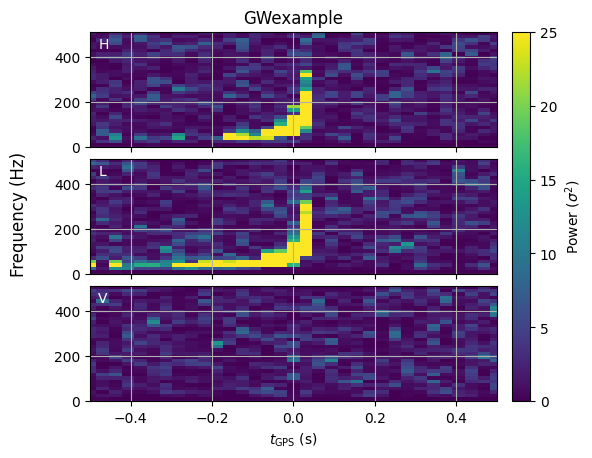

In [3]:
# plot the spectogram
event_data.specgram((-.5, .5))

### posteriors: unlensed & Type II lensed

In [4]:
# get the Posterior objects (lensed and unlensed) from the event data
prior_class = 'IntrinsicLVCPrior'
injection_dict = event_data.get_init_dict()['injection']
injected_par_dic = injection_dict['par_dic']
mchirp = cogwheel.gw_utils.m1m2_to_mchirp(injected_par_dic['m1'], injected_par_dic['m2'])

# Type II lensed: multiply the strain by i
event_data_lensed = event_data.reinstantiate(strain=1j*event_data.strain)

# instantiate a posterior (using the unlensed data)
post = cogwheel.posterior.Posterior.from_event(event_data, mchirp, injection_dict['approximant'], prior_class)

Setting reference from injection.


In [5]:
# get the model waveform evaluated at the max likelihood parameters
unlensed_h_f = post.likelihood._get_h_f(post.likelihood.par_dic_0)
# the model waveform at the max likelihood parameters is unlensed---let's Type II lens by multiplying by i
lensed_h_f = unlensed_h_f * 1j

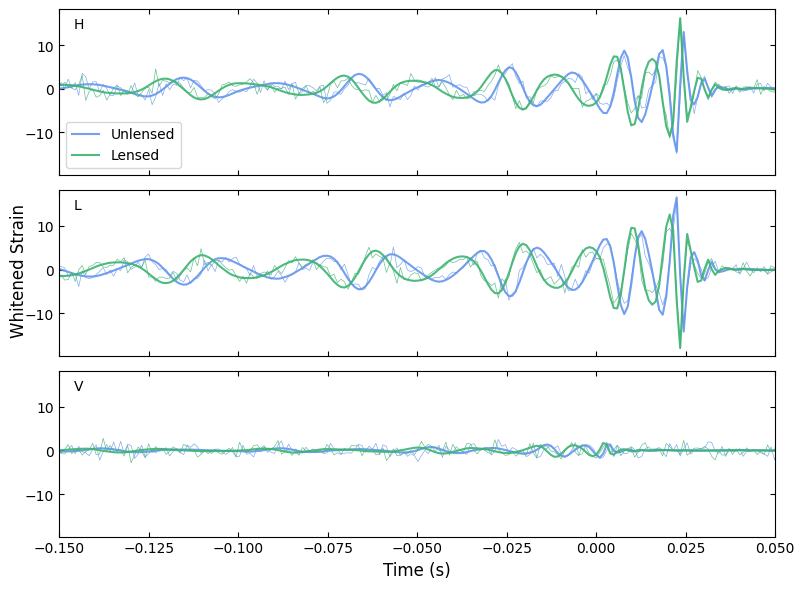

In [6]:
# plot these waveforms
fig = post.likelihood._setup_data_figure((8,6))
# fig, axs = plt.subplots(3, 1, figsize=(10,8))
axs = fig.get_axes()

for ed, h_f, label, c in zip([event_data, event_data_lensed],
                       [unlensed_h_f, lensed_h_f],
                       ['Unlensed', 'Lensed'],
                       ['cornflowerblue', 'mediumseagreen']):
    # apply a small time shift to align the relative binning
    times = ed.times - ed.tcoarse
    # strain
    data_t_wht = ed.get_whitened_td(ed.strain)
    # model waveform
    wf_t_wht = ed.get_whitened_td(h_f)

    for ax, data_det, wf_det in zip(axs, data_t_wht, wf_t_wht):
        ax.plot(times, data_det, c=c, alpha=0.8, lw=0.5)
        ax.plot(times, wf_det, c=c, alpha=0.9, label=label)
        ax.set_xlim(-0.15, 0.05)
    axs[0].legend()

### what went wrong in my code?

I _was_ accidentally multiplying the strain by $i$ twice, only in cases where I loaded in preexisting event data from the `.npz` generated from previous sampling. 

In [7]:
# ~ copied from my function run_parameter_estimation()
multiply_by_i = True
mchirp_guess = mchirp   # chirp mass: cheating but we can get this exactly
t_merger_guess = 0.
approximant = injection_dict['approximant']

# optionally, multiply the strain by i, i.e. pick up a Type II phase
if multiply_by_i:
    print(f"multiplying the strain by i")
    event_data_ = event_data.reinstantiate(strain=1j*event_data.strain)
else:
    event_data_ = event_data

# compute the posterior
posterior = cogwheel.posterior.Posterior.from_event(
    event_data_,
    mchirp_guess,
    approximant,
    prior_class,
    ref_wf_finder_kwargs={
        'f_ref': 100.0,  # Just so it matches the injection and it makes sense to compare parameters
        'time_range': (t_merger_guess - 0.1, t_merger_guess + 0.1)  # Edit if needed
    }
)

# instantiate a CoherentScoreLensing object
coherent_score = CoherentScoreLensing(**posterior.likelihood.coherent_score.get_init_dict())
# reinstantiate the likelihood
lensing_likelihood = posterior.likelihood.reinstantiate(coherent_score=coherent_score)
# now we can use the same prior with the lensing likelihood to instantiate a new posterior object
lensing_posterior = cogwheel.posterior.Posterior(prior=posterior.prior, likelihood=lensing_likelihood)

# instantiate a Nautilus object
sampler = cogwheel.sampling.Nautilus(lensing_posterior)
# get the run directory
rundir = sampler.get_rundir(parentdir='.')
# this is where we'd usually run the sampler, but I want to skip the sampling and just save the EventData as a .npz
# copied from sampler.run():
rundir = pathlib.Path(rundir)
sampler.to_json(rundir, dir_permissions=sampler.dir_permissions,
                file_permissions=sampler.file_permissions, overwrite=True)

multiplying the strain by i


Setting reference from injection.


In [8]:
# now load the event data that we just saved to the .npz
fn = os.path.join(os.getcwd(), rundir, eventname)
if os.path.exists(fn+'.npz'):
    event_data = cogwheel.data.EventData.from_npz(fn)
    #   this event_data.strain has already been lensed ! (but I forgot this!)
else:
    # generate new (unlensed) event data
    print(f"event_data does not exist at {fn}")
    # event_data = create_event_data() ...
    #   this is unlensed

# "Type II lens" the signal
event_data.strain *= 1j
# !! This is where I went wrong in my code---this event_data.strain is already lensed when I load it, but I still
#   multiply by i (so it's been multiplied by i twice i.e. flipped sign) and this is why the
#   waveform from the par_dic_0 is antiphase with the event data strain.

In [9]:
# get the best-fit waveform from the injected parameters:
#   the injection doesn't "know" that we've lensed the signal
injection_dict = event_data.get_init_dict()['injection']
injected_par_dic = injection_dict['par_dic']
mchirp = cogwheel.gw_utils.m1m2_to_mchirp(injected_par_dic['m1'], injected_par_dic['m2'])
post = cogwheel.posterior.Posterior.from_event(event_data, mchirp, injection_dict['approximant'], prior_class)
coherent_score = CoherentScoreLensing(**post.likelihood.coherent_score.get_init_dict())
lensing_likelihood = post.likelihood.reinstantiate(coherent_score=coherent_score)

Setting reference from injection.


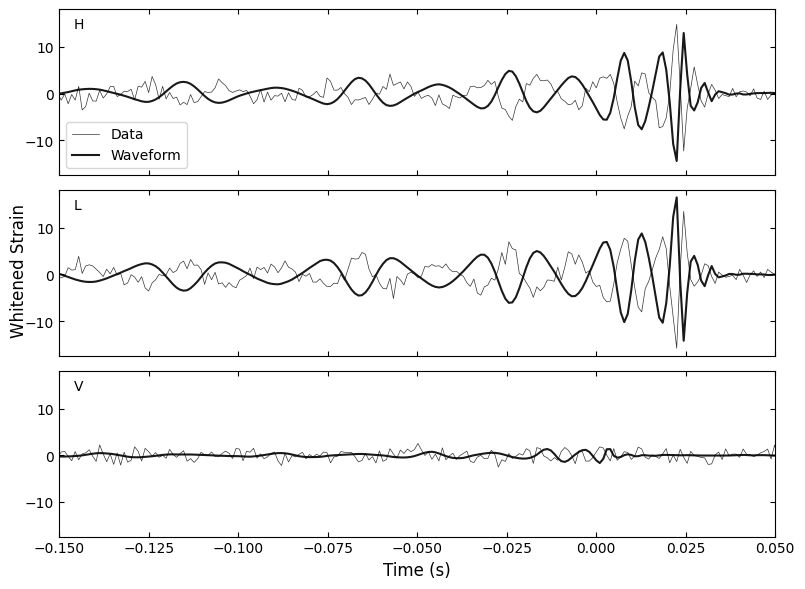

In [10]:
fig = post.likelihood._setup_data_figure((8,6))
axs = fig.get_axes()

# apply a small time shift to align the relative binning
times = event_data.times - event_data.tcoarse
# strain
data_t_wht = event_data.get_whitened_td(event_data.strain)
# model waveform
wf_t_wht = event_data.get_whitened_td(lensing_likelihood._get_h_f(lensing_likelihood.par_dic_0))

for ax, data_det, wf_det in zip(axs, data_t_wht, wf_t_wht):
    ax.plot(times, data_det, c='k', alpha=0.8, lw=0.5, label='Data')
    ax.plot(times, wf_det, c='k', alpha=0.9, label='Waveform')
    ax.set_xlim(-0.15, 0.05)
axs[0].legend()

In [11]:
# this is why the waveform is antiphase with the event_data.strain